# Gabarito — Funções

Este notebook traz a resolução comentada dos exercícios de [`015a_funcoes.ipynb`](015a_funcoes.ipynb).

⚠️ **Antes de olhar aqui:** tente resolver os exercícios sozinho no notebook original e use as células de verificação (`assert`) para conferir sua resposta. Volte a este gabarito só depois de tentar — ou se travar de verdade em algum passo.

In [2]:
# Funções e imports auxiliares definidos no notebook principal, necessários
# para os exercícios abaixo.
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

NORD_FUNDO = "#2E3440"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_DESTAQUE = "#A3BE8C"

x = sp.symbols("x")


def eh_funcao(conjunto_a: set, flechas: list[tuple]) -> bool:
    '''Verifica se as flechas (pares (a, b)) definem uma função de conjunto_a em B.'''
    origens = [a for a, _ in flechas]
    existencia = all(a in origens for a in conjunto_a)
    unicidade = len(origens) == len(set(origens))
    return existencia and unicidade

## Básico

**Exercício 1.** Para cada relação de A_ex em B_ex, diga se é função.

In [3]:
A_ex = {1, 2, 3, 4}
B_ex = {10, 20, 30}

relacao_1 = [(1, 10), (2, 10), (3, 20), (4, 30)]
relacao_2 = [(1, 10), (2, 20), (3, 30)]
relacao_3 = [(1, 10), (1, 20), (2, 10), (3, 20), (4, 30)]

# relacao_1: todo elemento de A_ex (1,2,3,4) aparece em exatamente uma flecha -> função
eh_funcao_1 = eh_funcao(A_ex, relacao_1)

# relacao_2: falta o elemento 4 de A_ex (ninguém aponta a partir dele) -> não é função
eh_funcao_2 = eh_funcao(A_ex, relacao_2)

# relacao_3: o elemento 1 tem duas flechas (para 10 e para 20) -> não é função
eh_funcao_3 = eh_funcao(A_ex, relacao_3)

print(eh_funcao_1, eh_funcao_2, eh_funcao_3)

True False False


**Exercício 2.** Calcule f(2), f(-1) e f(0) para f(x) = 3x² - x + 1.

In [4]:
def f_ex(x):
    return 3 * x**2 - x + 1


# f_ex(2)  = 3*4 - 2 + 1 = 11
f_de_2 = f_ex(2)
# f_ex(-1) = 3*1 - (-1) + 1 = 5
f_de_menos1 = f_ex(-1)
# f_ex(0)  = 3*0 - 0 + 1 = 1
f_de_0 = f_ex(0)

print(f_de_2, f_de_menos1, f_de_0)

11 5 1


## Intermediário

**Exercício 1.** Determine o domínio de validade de f_int(x) = 1/(x-3) e g_int(x) = √(2x-4).

In [5]:
f_int_expr = 1 / (x - 3)
g_int_expr = sp.sqrt(2 * x - 4)

# denominador x-3 != 0 -> x != 3 -> domínio = R - {3}
dominio_f_int = sp.calculus.util.continuous_domain(f_int_expr, x, sp.S.Reals)

# radicando 2x-4 >= 0 -> x >= 2 -> domínio = [2, +infinito)
dominio_g_int = sp.calculus.util.continuous_domain(g_int_expr, x, sp.S.Reals)

print(dominio_f_int, dominio_g_int)

Union(Interval.open(-oo, 3), Interval.open(3, oo)) Interval(2, oo)


**Exercício 2.** Resolva a inequação 3x - 5 > 2x + 1 e escreva o conjunto-solução como um intervalo.

In [6]:
# 3x - 5 > 2x + 1
# 3x - 2x > 1 + 5   (subtrai 2x e soma 5 dos dois lados, sinal não muda)
# x > 6
conjunto_solucao_ex = sp.Interval.open(6, sp.oo)

print(conjunto_solucao_ex)

Interval.open(6, oo)


## Desafio

**Exercício 1.** f_des(x) = (x²-4)/(x-2) e g_des(x) = x+2 são a mesma função?

In [7]:
f_des_expr = (x**2 - 4) / (x - 2)
g_des_expr = x + 2

# f_des_expr simplifica algebricamente para x+2, mas fica indefinida em x=2
# (denominador zero) -> o domínio de f_des e R-{2}, diferente do domínio de
# g_des (R inteiro). Mesma formula simplificada, domínios diferentes -> NÃO
# são a mesma função.
dominio_f_des = sp.calculus.util.continuous_domain(f_des_expr, x, sp.S.Reals)
dominio_g_des = sp.calculus.util.continuous_domain(g_des_expr, x, sp.S.Reals)
funcoes_iguais_ex = dominio_f_des == dominio_g_des

print(f"Domínio de f_des: {dominio_f_des}")
print(f"Domínio de g_des: {dominio_g_des}")
print(f"São a mesma função? {funcoes_iguais_ex}")

Domínio de f_des: Union(Interval.open(-oo, 2), Interval.open(2, oo))
Domínio de g_des: Reals
São a mesma função? False


**Exercício 2.** Dado o gráfico de uma função definida por partes, identifique domínio, imagem e zeros.

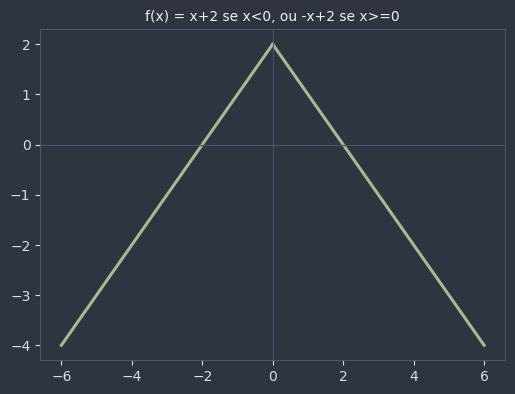

Interval(-oo, oo) Interval(-oo, 2) {2, -2}


In [8]:
def f_partes(valor):
    return valor + 2 if valor < 0 else -valor + 2


xs_partes_esq = np.linspace(-6, 0, 200)
xs_partes_dir = np.linspace(0, 6, 200)
fig, ax = plt.subplots(figsize=(6, 4.3))
fig.patch.set_facecolor(NORD_FUNDO)
ax.set_facecolor(NORD_FUNDO)
ax.plot(xs_partes_esq, xs_partes_esq + 2, color=COR_DESTAQUE, linewidth=2.2)
ax.plot(xs_partes_dir, -xs_partes_dir + 2, color=COR_DESTAQUE, linewidth=2.2)
ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
ax.tick_params(colors=NORD_TEXTO_SEC)
for spine in ax.spines.values():
    spine.set_color(NORD_LINHA)
ax.set_title("f(x) = x+2 se x<0, ou -x+2 se x>=0", color=NORD_TEXTO, fontsize=10)
plt.show()

# as duas partes juntas cobrem todo x<0 (ramo esquerdo) e todo x>=0 (ramo
# direito) -> nenhum real fica de fora -> domínio = R
dominio_partes_ex = sp.Interval(-sp.oo, sp.oo)

# o pico acontece em x=0, onde f(0)=2 (o máximo). Os dois ramos caem sem
# limite (para -infinito) conforme x se afasta de 0 -> imagem = (-infinito, 2]
imagem_partes_ex = sp.Interval(-sp.oo, 2)

# zero do ramo esquerdo (válido para x<0): x+2=0 -> x=-2
# zero do ramo direito  (válido para x>=0): -x+2=0 -> x=2
zeros_partes_ex = {-2, 2}

print(dominio_partes_ex, imagem_partes_ex, zeros_partes_ex)